<a href="https://colab.research.google.com/github/adam01051/computer_vision/blob/main/torch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install torch

In [2]:
import torch

In [12]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [13]:
scalar = torch.tensor(5)  # 0D
print("scalar:", scalar)
print("Shape:", scalar.shape)
print("Number of Dimensions:", scalar.ndim)
print("Size:", scalar.size())

scalar: tensor(5)
Shape: torch.Size([])
Number of Dimensions: 0
Size: torch.Size([])


In [14]:
vector = torch.tensor([1, 2, 3])  # 1D
print("vector:", vector)
print("Shape:", vector.shape)
print("Number of Dimensions:", vector.ndim)
print("Size:", vector.size())

vector: tensor([1, 2, 3])
Shape: torch.Size([3])
Number of Dimensions: 1
Size: torch.Size([3])


In [15]:
MATRIX = torch.tensor([[1, 2, 3],
                       [4, 5, 6]])  # 2D

print("MATRIX:", MATRIX)
print("Shape:", MATRIX.shape)
print("Number of Dimensions:", MATRIX.ndim)

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])
Shape: torch.Size([2, 3])
Number of Dimensions: 2


In [16]:
tensor3d = torch.stack([MATRIX, MATRIX + 10])  # 3D
print('tensor3d:', tensor3d)
print('Shape:', tensor3d.shape)  # [2, 2, 3] | 2 matrices => channels | 2 rows | 3 columns
print('Number of Dimensions:', tensor3d.ndim)

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
Shape: torch.Size([2, 2, 3])
Number of Dimensions: 3


In [17]:
random_numbers = torch.rand(2, 3)  # 0 ~ 1
print('Random Numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Data type:',)

Random Numbers: tensor([[0.7172, 0.4249, 0.9265],
        [0.7449, 0.7288, 0.3358]])
Data type: torch.float32
Data type:


In [18]:
print('Zeros:', torch.zeros(3, 3))

Zeros: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [19]:
print('Ones:', torch.ones(2, 4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [20]:
x = torch.tensor([[1, 2],
                  [3, 4]])

y = torch.tensor([[5, 6],
                  [7, 8]])

# Element-wise addition
print('Addition:', x + y)
print('================')

# Element-wise multiplication
print('Multiplication:', x * y)
print('================')

# Matrix multiplication
print('Matrix @ multiplication:', x @ y)

# x
# [[1, 2],
#  [3, 4]]

# y
# [[5, 6],
#  [7, 8]]

Addition: tensor([[ 6,  8],
        [10, 12]])
Multiplication: tensor([[ 5, 12],
        [21, 32]])
Matrix @ multiplication: tensor([[19, 22],
        [43, 50]])


In [21]:
#111


In [22]:

import torch
from torch import nn
import matplotlib.pyplot as plt


torch.__version__

'2.11.0+cu128'

In [23]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [24]:

w = 0.7
b = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim=1)
y = w * X + b

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [25]:

weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

print("X:", X)

print("\n y:", y)

# Split data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

X: tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800],
        [0.2000],
        [0.2200],
        [0.2400],
        [0.2600],
        [0.2800],
        [0.3000],
        [0.3200],
        [0.3400],
        [0.3600],
        [0.3800],
        [0.4000],
        [0.4200],
        [0.4400],
        [0.4600],
        [0.4800],
        [0.5000],
        [0.5200],
        [0.5400],
        [0.5600],
        [0.5800],
        [0.6000],
        [0.6200],
        [0.6400],
        [0.6600],
        [0.6800],
        [0.7000],
        [0.7200],
        [0.7400],
        [0.7600],
        [0.7800],
        [0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

 y: tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
 

(40, 40, 10, 10)

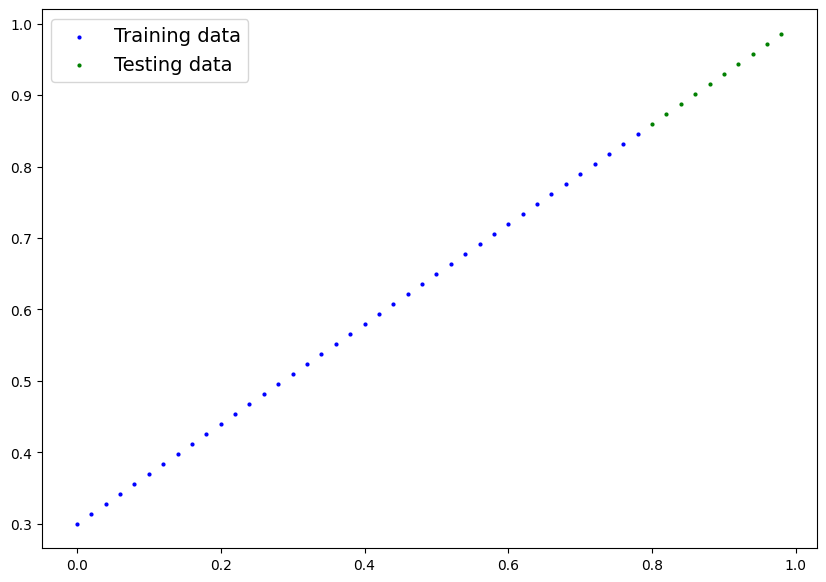

In [27]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):

    plt.figure(figsize=(10, 7))


    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')


    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    plt.legend(prop={"size": 14})


plot_predictions()

In [28]:

class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()


        self.linear_layer = nn.Linear(
            in_features=1,
            out_features=1
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)



torch.manual_seed(42)

model_1 = LinearRegressionModelV2()

model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

Text(0.5, 1.0, 'Predictions  (red = random guesses)')

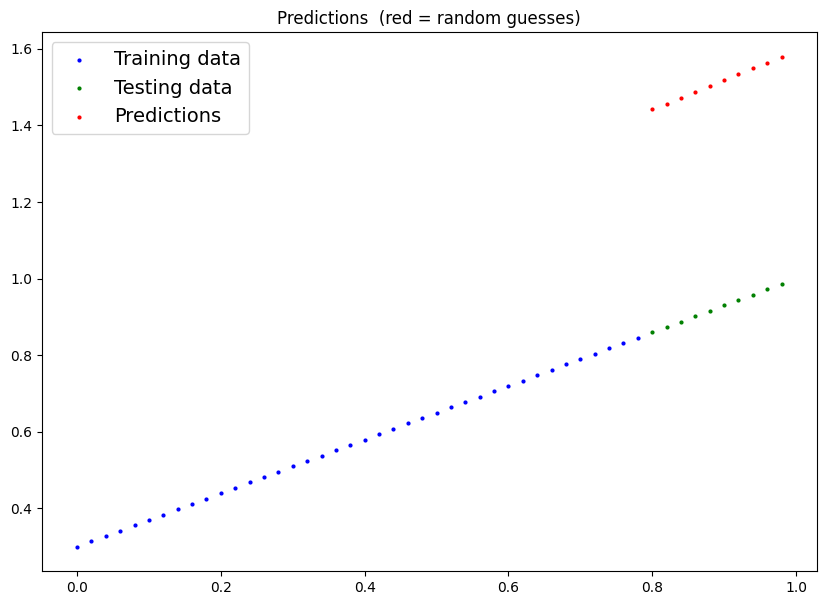

In [30]:


model_1.eval()

with torch.inference_mode():
    y_preds_early = model_1(X_test)

plot_predictions(predictions=y_preds_early)

plt.title("Predictions  (red = random guesses)")

In [33]:

epochs = 1000

X_train = X_train.to(device)
X_test = X_test.to(device)

y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):


    model_1.train()

    y_pred = model_1(X_train)


    loss = loss_fn(y_pred, y_train)


    optimizer.zero_grad()

    loss.backward()


    optimizer.step()


    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)

        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [35]:

model_1.eval()


with torch.inference_mode():
    y_preds = model_1(X_test)

y_preds

RuntimeError: Expected all tensors to be on the same device, but got mat1 is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA_addmm)

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [ ]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()